## Split Distribution Check (Train / Validation / Test)

Before training **MelCNN MGR**, we should sanity-check that the **genre proportions** across **train**, **validation**, and **test** are not wildly different. In this project, our working meaning of **“same distribution shape”** is:

> The **ratios of samples per genre** (class proportions) in train/val/test are **roughly similar**, so evaluation isn’t distorted by one split containing disproportionately more (or fewer) samples from certain genres.
>
> In other words, in MelCNN MGR project, it’s preferable (though not strictly required) that train/validation/test have similar genre proportions, because it reduces the chance that performance differences are driven by a different class mix rather than MFCC vs log-mel (Goal 1) or optimization choices (Goal 2). Since FMA provides an official split in fma_metadata/tracks.csv, the best practice is to use that split for comparability and to avoid leakage traps, then measure and report genre proportions as a “distribution-shape” sanity check. If proportions differ noticeably, the evaluation remains valid, but results should emphasize Macro-F1 and per-genre F1, and may optionally use class-weighted loss.

### Important note about FMA-small

According to the official FMA repository, **FMA-small** contains **8,000 tracks of 30 seconds across 8 balanced genres**.

So if this notebook is configured for **exact small** and you still see many more than 8 genres, something is wrong with the filtering logic.
The most common mistake is treating subset labels as plain strings and comparing them lexicographically.
For example, using a condition like `tracks[("set", "subset")] <= "small"` does **not** mean “exact small”; it can accidentally include `medium` and `large` rows too.

This notebook therefore separates two modes explicitly:

- `SUBSET_MODE = "exact"`: use only rows whose exact subset label matches `SUBSET`
- `SUBSET_MODE = "cumulative"`: use the cumulative FMA convention `small ⊂ medium ⊂ large`

### What we will compute

Using FMA metadata (`tracks.csv`), where:
- split is stored in `('set', 'split')` ∈ {`training`, `validation`, `test`}
- genre label is stored in `('track', 'genre_top')`

We will compute:

1) **Counts per genre per split**  
   A table like: rows = genres, columns = {train, val, test}

2) **Proportions per genre per split**  
   Same table but normalized so each split sums to 1.

3) **Drift ratios** (easy to interpret)  
   For each genre `g`, compute:
   - `p_test(g) / p_train(g)`
   - `p_val(g)  / p_train(g)`
   
   Values near **1.0** mean the split proportions match closely.
   Large deviations suggest distribution shift in class mix.

4) **One-number distance summaries** (optional but useful)
- **Total Variation Distance (TVD)**:  
  \[
  \text{TVD}(p, q) = \frac{1}{2}\sum_g |p(g) - q(g)|
  \]
  where `p(g)` and `q(g)` are genre proportions in two splits.

- **Jensen–Shannon Divergence (JSD)** (symmetric + stable):
  a bounded measure of how different two distributions are.

### How we will compare

We’ll use:
- A **bar chart** (genre proportions across splits) for quick visual sanity.
- A **drift ratio table** to spot which genres differ most.
- (Optional) TVD/JSD to summarize “how different” the splits are with a single value.

### Interpretation

- Minor differences are normal and acceptable.
- If some genres have big drift (e.g., 2× higher in test than train), metrics like **accuracy** can be misleading.
- That’s why we will report **Macro-F1** and **per-genre F1** (not just accuracy), since FMA-medium is unbalanced.

This check does **not** change the official FMA split; it simply makes our evaluation assumptions explicit and auditable.

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Dataset scope configuration ───────────────────────────────────────────────
# SUBSET selects the target FMA subset label.
# Set to "small", "medium", "large", or None (no filter — all tracks).
SUBSET = "small"

# SUBSET_MODE controls whether the subset filter is exact or cumulative.
# - "exact"      : only rows whose exact subset label equals SUBSET
# - "cumulative" : FMA-style cumulative view, e.g. medium = small ∪ medium
#
# If you want to match the official FMA-small claim (8000 tracks, 8 balanced genres),
# use SUBSET="small" with SUBSET_MODE="exact".
SUBSET_MODE = "exact"

# Optional: focus plots/tables on the head of the distribution.
# Set to an integer such as 8 or 10, or leave as None to keep all genres.
TOP_N_GENRES = 8


In [18]:

# Load metadata (adjust path)
tracks = pd.read_csv("../../FMA/fma_metadata/tracks.csv", header=[0,1], index_col=0)

# ── Apply subset filter safely ───────────────────────────────────────────────
# IMPORTANT:
# Do not compare subset labels as plain strings such as <= "small".
# That is a lexicographic comparison, not FMA subset logic, and it can include
# unintended rows from medium/large. Use an explicit ordered mapping instead.
subset_order = ["small", "medium", "large"]

if SUBSET is None:
    _subset_label = "all subsets"
else:
    if SUBSET not in subset_order:
        raise ValueError(f"Unsupported SUBSET={SUBSET!r}; expected one of {subset_order} or None")
    if SUBSET_MODE == "exact":
        tracks = tracks[tracks[("set", "subset")] == SUBSET]
        _subset_label = f"fma_{SUBSET} (exact)"
    elif SUBSET_MODE == "cumulative":
        allowed_subsets = subset_order[:subset_order.index(SUBSET) + 1]
        tracks = tracks[tracks[("set", "subset")].isin(allowed_subsets)]
        _subset_label = f"fma_{SUBSET} (cumulative: {', '.join(allowed_subsets)})"
    else:
        raise ValueError("SUBSET_MODE must be 'exact' or 'cumulative'")

print(f"Subset filter : SUBSET={SUBSET!r}, SUBSET_MODE={SUBSET_MODE!r}")
print(f"Tracks kept   : {len(tracks):,} ({_subset_label})")


Subset filter : SUBSET='small', SUBSET_MODE='exact'
Tracks kept   : 8,000 (fma_small (exact))


## Whole-Dataset EDA

Before comparing train / validation / test distributions, it helps to understand the selected dataset as a whole.

This section summarizes:
- overall track counts after the current subset filter,
- label coverage (`genre_top` present vs missing),
- split composition,
- subset composition,
- genre imbalance across the whole labeled dataset,
- and basic duration distributions.

This gives broader context for later split-level diagnostics.

In [19]:
# ── Whole-dataset summary tables ─────────────────────────────────────────────
full_df = tracks[[
    ("set", "subset"),
    ("set", "split"),
    ("track", "genre_top"),
    ("track", "duration"),
    ("track", "bit_rate"),
]].copy()
full_df.columns = ["subset", "split", "genre", "duration_s", "bit_rate"]

labeled_df = full_df[full_df["genre"].notna()].copy()
unlabeled_df = full_df[full_df["genre"].isna()].copy()

print("=" * 72)
print(f"Whole-dataset EDA for {_subset_label}")
print("=" * 72)
print(f"Total tracks after subset filter : {len(full_df):,}")
print(f"Labeled tracks (genre_top)      : {len(labeled_df):,} ({len(labeled_df)/len(full_df):.1%})")
print(f"Unlabeled tracks                : {len(unlabeled_df):,} ({len(unlabeled_df)/len(full_df):.1%})")
print()

subset_counts = full_df["subset"].value_counts().sort_index()
print("Tracks by exact FMA subset label:")
print(subset_counts.to_string())
print()

split_counts_all = full_df["split"].fillna("<missing>").value_counts()
print("Tracks by official split (including unlabeled rows):")
print(split_counts_all.to_string())
print()

split_counts_labeled = labeled_df["split"].value_counts()
print("Labeled tracks by split:")
print(split_counts_labeled.to_string())
print()

whole_genre_counts = labeled_df["genre"].value_counts().sort_values(ascending=False)
whole_genre_share = (whole_genre_counts / whole_genre_counts.sum()).rename("share")
whole_genre_summary = pd.concat(
    [whole_genre_counts.rename("count"), whole_genre_share],
    axis=1,
)
whole_genre_summary["share"] = whole_genre_summary["share"].map(lambda x: f"{x:.2%}")

if TOP_N_GENRES is None:
    display_genre_summary = whole_genre_summary
    display_genre_label = "all genres"
else:
    display_genre_summary = whole_genre_summary.head(TOP_N_GENRES)
    display_genre_label = f"top {TOP_N_GENRES} genres"

print(f"Number of labeled genres        : {whole_genre_counts.size}")
print(f"Showing {display_genre_label} in the summary table below:")
print(display_genre_summary.to_string())
print()

# Sanity check: exact FMA-small should have 8 labeled genres.
if SUBSET == "small" and SUBSET_MODE == "exact":
    print("Sanity check for exact FMA-small:")
    print(f"  Expected labeled genres ≈ 8, observed = {whole_genre_counts.size}")
    print(f"  Expected total tracks   = 8,000, observed = {len(full_df):,}")
    print()

n_max = int(whole_genre_counts.max())
ratio_table = (whole_genre_counts / n_max).rename("r_c")
ratio_summary = pd.concat([whole_genre_counts.rename("count"), ratio_table], axis=1)
ratio_summary["oversample_band"] = ratio_summary["r_c"].between(0.05, 0.2, inclusive="right")
print("Genres in the practical supplementation band (0.05 < r_c <= 0.2):")
print(ratio_summary[ratio_summary["oversample_band"]].to_string())

Whole-dataset EDA for fma_small (exact)
Total tracks after subset filter : 8,000
Labeled tracks (genre_top)      : 8,000 (100.0%)
Unlabeled tracks                : 0 (0.0%)

Tracks by exact FMA subset label:
subset
small    8000

Tracks by official split (including unlabeled rows):
split
training      6400
validation     800
test           800

Labeled tracks by split:
split
training      6400
validation     800
test           800

Number of labeled genres        : 8
Showing top 8 genres in the summary table below:
               count   share
genre                       
Hip-Hop         1000  12.50%
Pop             1000  12.50%
Folk            1000  12.50%
Experimental    1000  12.50%
Rock            1000  12.50%
International   1000  12.50%
Electronic      1000  12.50%
Instrumental    1000  12.50%

Sanity check for exact FMA-small:
  Expected labeled genres ≈ 8, observed = 8
  Expected total tracks   = 8,000, observed = 8,000

Genres in the practical supplementation band (0.05 < r_c 

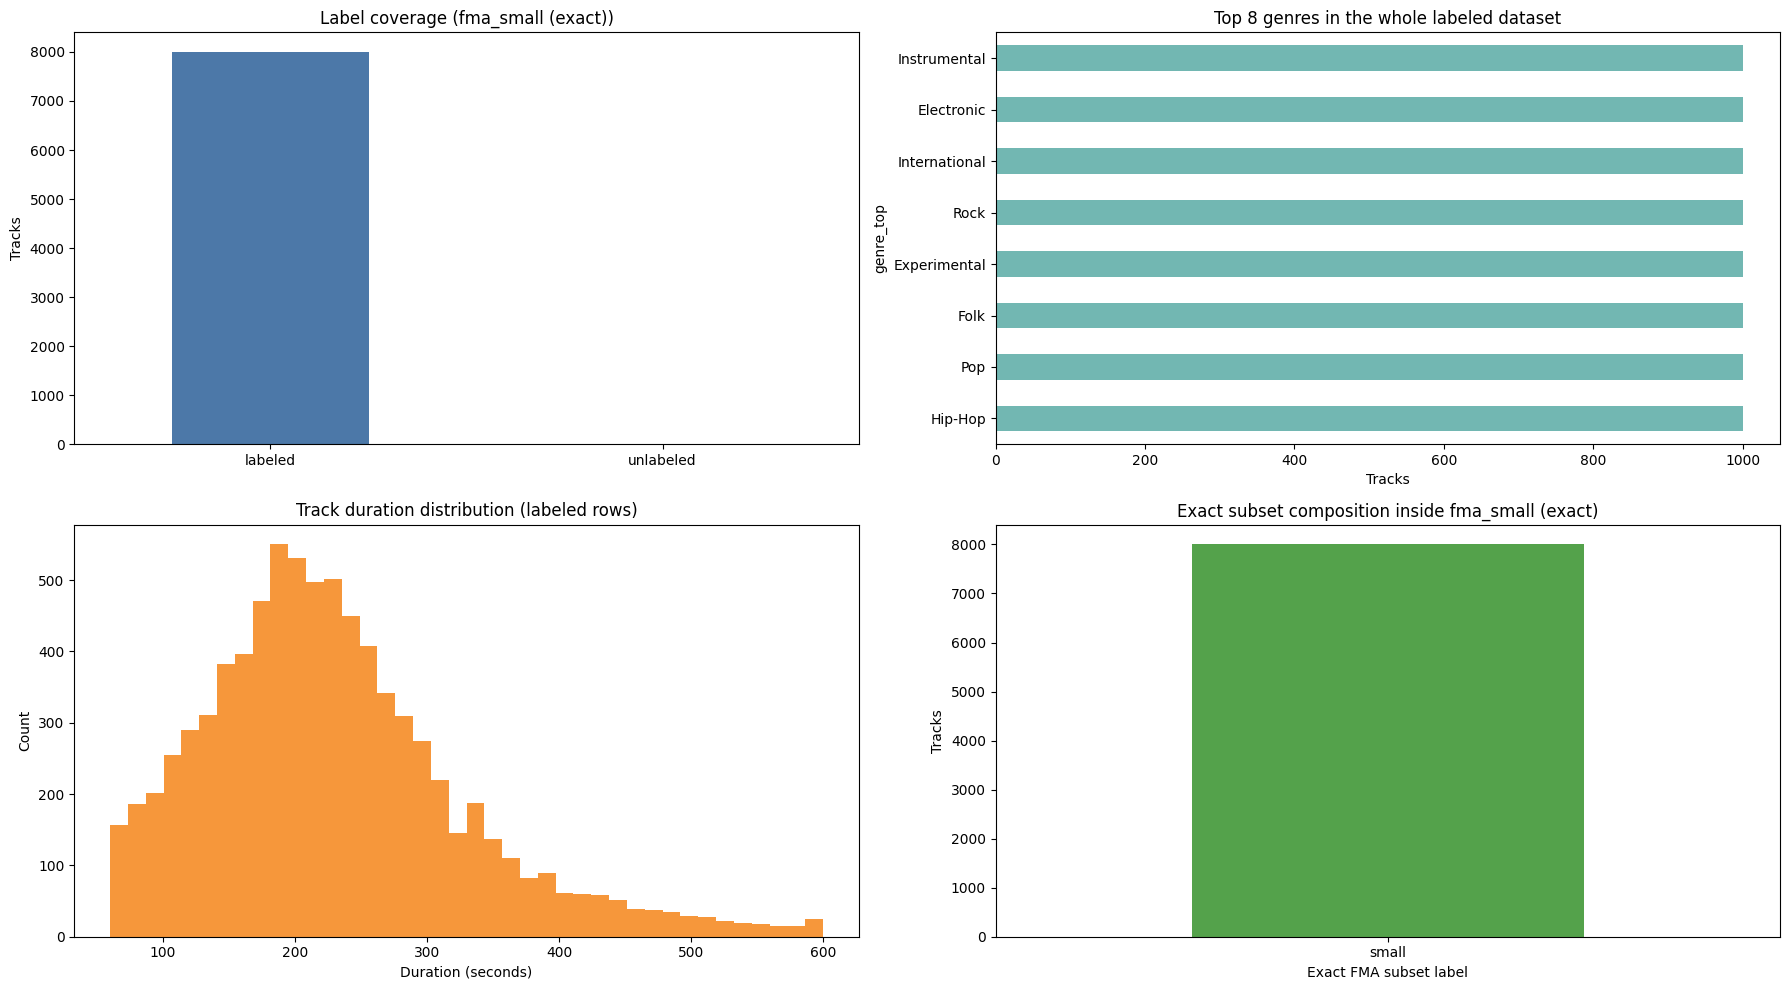

Whole-dataset duration summary (labeled rows):
count    8000.00
mean      228.84
std        98.39
min        60.00
10%       114.00
25%       161.00
50%       215.00
75%       279.00
90%       356.00
max       600.00

Most imbalanced genres in the whole labeled dataset (smallest r_c):
               count  r_c  oversample_band
genre                                     
Hip-Hop         1000  1.0            False
Pop             1000  1.0            False
Folk            1000  1.0            False
Experimental    1000  1.0            False
Rock            1000  1.0            False
International   1000  1.0            False
Electronic      1000  1.0            False
Instrumental    1000  1.0            False


In [20]:
# ── Whole-dataset plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# A) Labeled vs unlabeled coverage
coverage_counts = pd.Series(
    {"labeled": len(labeled_df), "unlabeled": len(unlabeled_df)}
)
coverage_counts.plot(kind="bar", ax=axes[0, 0], color=["#4C78A8", "#E45756"])
axes[0, 0].set_title(f"Label coverage ({_subset_label})")
axes[0, 0].set_ylabel("Tracks")
axes[0, 0].tick_params(axis="x", rotation=0)

# B) Whole-dataset genre distribution
plot_genre_counts = whole_genre_counts if TOP_N_GENRES is None else whole_genre_counts.head(TOP_N_GENRES)
plot_genre_counts = plot_genre_counts.sort_values(ascending=True)
plot_genre_counts.plot(kind="barh", ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title(
    f"{'All' if TOP_N_GENRES is None else f'Top {TOP_N_GENRES}'} genres in the whole labeled dataset"
)
axes[0, 1].set_xlabel("Tracks")
axes[0, 1].set_ylabel("genre_top")

# C) Duration distribution
labeled_duration = labeled_df["duration_s"].dropna()
axes[1, 0].hist(labeled_duration, bins=40, color="#F58518", alpha=0.85)
axes[1, 0].set_title("Track duration distribution (labeled rows)")
axes[1, 0].set_xlabel("Duration (seconds)")
axes[1, 0].set_ylabel("Count")

# D) Exact subset composition
subset_counts.sort_index().plot(kind="bar", ax=axes[1, 1], color="#54A24B")
axes[1, 1].set_title(f"Exact subset composition inside {_subset_label}")
axes[1, 1].set_xlabel("Exact FMA subset label")
axes[1, 1].set_ylabel("Tracks")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Whole-dataset duration summary (labeled rows):")
print(labeled_duration.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2).to_string())

print()
print("Most imbalanced genres in the whole labeled dataset (smallest r_c):")
print(ratio_summary.sort_values("r_c").head(10).to_string())

Counts:
 split          test  training  validation
genre                                    
Electronic      100       800         100
Experimental    100       800         100
Folk            100       800         100
Hip-Hop         100       800         100
Instrumental    100       800         100
International   100       800         100
Pop             100       800         100
Rock            100       800         100

Proportions:
 split           test  training  validation
genre                                     
Electronic     0.125     0.125       0.125
Experimental   0.125     0.125       0.125
Folk           0.125     0.125       0.125
Hip-Hop        0.125     0.125       0.125
Instrumental   0.125     0.125       0.125
International  0.125     0.125       0.125
Pop            0.125     0.125       0.125
Rock           0.125     0.125       0.125

Using top 8 genres for split plots: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop',

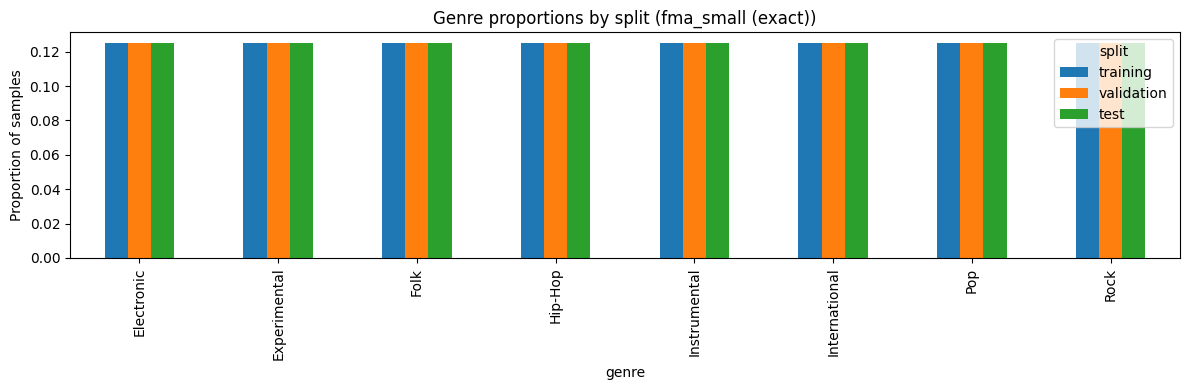


Drift ratios (closer to 1 is better):
                test/train  val/train
genre                               
Electronic            1.0        1.0
Experimental          1.0        1.0
Folk                  1.0        1.0
Hip-Hop               1.0        1.0
Instrumental          1.0        1.0
International         1.0        1.0
Pop                   1.0        1.0
Rock                  1.0        1.0

TVD(train, val):  0.0
TVD(train, test): 0.0
JSD(train, val):  0.0
JSD(train, test): 0.0


In [21]:

# Keep only the columns we need
df = tracks[[("set","split"), ("track","genre_top")]].dropna()
df.columns = ["split", "genre"]

# 1) Counts and proportions
counts = pd.crosstab(df["genre"], df["split"]).sort_index()
props = counts / counts.sum(axis=0)

print("Counts:\n", counts)
print("\nProportions:\n", props)

# Optional view focused on the head of the distribution.
if TOP_N_GENRES is None:
    counts_view = counts
    props_view = props
    print("\nUsing all genres for split plots.")
else:
    top_genres = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N_GENRES).index
    counts_view = counts.loc[top_genres]
    props_view = props.loc[top_genres]
    print(f"\nUsing top {TOP_N_GENRES} genres for split plots: {list(top_genres)}")

# 2A) Plot proportions
ax = props_view[["training","validation","test"]].plot(kind="bar", figsize=(12,4))
ax.set_ylabel("Proportion of samples")
ax.set_title(f"Genre proportions by split ({_subset_label})")
plt.tight_layout()
plt.show()

# 2B) Per-genre drift ratios (test/train, val/train)
drift = pd.DataFrame({
    "test/train": props["test"] / props["training"],
    "val/train":  props["validation"] / props["training"],
})
print("\nDrift ratios (closer to 1 is better):\n", drift.sort_values("test/train"))

# 2C) Distances: TVD and JSD
def tvd(p, q):
    return 0.5 * np.abs(p - q).sum()

def jsd(p, q, eps=1e-12):
    # Jensen-Shannon divergence (base 2)
    p = np.clip(p, eps, 1); p = p / p.sum()
    q = np.clip(q, eps, 1); q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log2(p / m))
    kl_qm = np.sum(q * np.log2(q / m))
    return 0.5 * (kl_pm + kl_qm)

genres = props.index
p_train = props["training"].reindex(genres).fillna(0).to_numpy()
p_val   = props["validation"].reindex(genres).fillna(0).to_numpy()
p_test  = props["test"].reindex(genres).fillna(0).to_numpy()

print("\nTVD(train, val): ", tvd(p_train, p_val))
print("TVD(train, test):", tvd(p_train, p_test))
print("JSD(train, val): ", jsd(p_train, p_val))
print("JSD(train, test):", jsd(p_train, p_test))


In [22]:

from scipy.stats import entropy as scipy_entropy

# ── A) Split-level summary ────────────────────────────────────────────────────
total_tracks   = len(tracks)
labeled_tracks = len(df)
missing_labels = total_tracks - labeled_tracks

split_sizes = df["split"].value_counts().rename("labeled_tracks")
split_summary = pd.DataFrame(split_sizes)
split_summary.index.name = "split"
print("=" * 60)
print(f"Subset filter    : {SUBSET!r} ({_subset_label})")
print(f"Total tracks     : {total_tracks:,}")
print(f"Tracks with genre_top: {labeled_tracks:,}")
print(f"Missing genre_top    : {missing_labels:,} ({missing_labels/total_tracks:.1%})")
print()
print("Labeled tracks per split:")
print(split_summary.to_string())
print()

# ── B) Class-imbalance ratio per split ───────────────────────────────────────
print("=" * 60)
print("Class imbalance ratio (max_count / min_count) per split:")
for split in ["training", "validation", "test"]:
    col  = counts[split]
    ratio = col.max() / col.min()
    print(f"  {split:<12}: {col.max():>5} (max: {col.idxmax()}) / "
          f"{col.min():>4} (min: {col.idxmin()}) → ratio = {ratio:.1f}×")
print()

# ── C) Shannon entropy & effective number of classes per split ───────────────
n_classes = len(counts)
print("=" * 60)
print("Shannon entropy & effective number of classes per split:")
print(f"  (max possible entropy for {n_classes} classes = {np.log(n_classes):.4f} nats)")
for split in ["training", "validation", "test"]:
    p    = counts[split] / counts[split].sum()
    h    = scipy_entropy(p)           # nats
    enc  = np.exp(h)                  # effective N classes
    print(f"  {split:<12}: H = {h:.4f} nats,  effective classes = {enc:.1f}")
print()

# ── D) Per-genre descriptive stats across splits ──────────────────────────────
print("=" * 60)
print("Per-genre count descriptives (mean / std / min / max across train+val+test):")
genre_stats = counts[["training", "validation", "test"]].agg(
    ["mean", "std", "min", "max"], axis=1
).round(1)
genre_stats.columns = ["mean", "std", "min", "max"]
genre_stats["cv%"] = (genre_stats["std"] / genre_stats["mean"] * 100).round(1)
genre_stats = genre_stats.sort_values("mean", ascending=False)
print(genre_stats.to_string())


Subset filter    : 'small' (fma_small (exact))
Total tracks     : 8,000
Tracks with genre_top: 8,000
Missing genre_top    : 0 (0.0%)

Labeled tracks per split:
            labeled_tracks
split                     
training              6400
validation             800
test                   800

Class imbalance ratio (max_count / min_count) per split:
  training    :   800 (max: Electronic) /  800 (min: Electronic) → ratio = 1.0×
  validation  :   100 (max: Electronic) /  100 (min: Electronic) → ratio = 1.0×
  test        :   100 (max: Electronic) /  100 (min: Electronic) → ratio = 1.0×

Shannon entropy & effective number of classes per split:
  (max possible entropy for 8 classes = 2.0794 nats)
  training    : H = 2.0794 nats,  effective classes = 8.0
  validation  : H = 2.0794 nats,  effective classes = 8.0
  test        : H = 2.0794 nats,  effective classes = 8.0

Per-genre count descriptives (mean / std / min / max across train+val+test):
                mean    std    min    max   

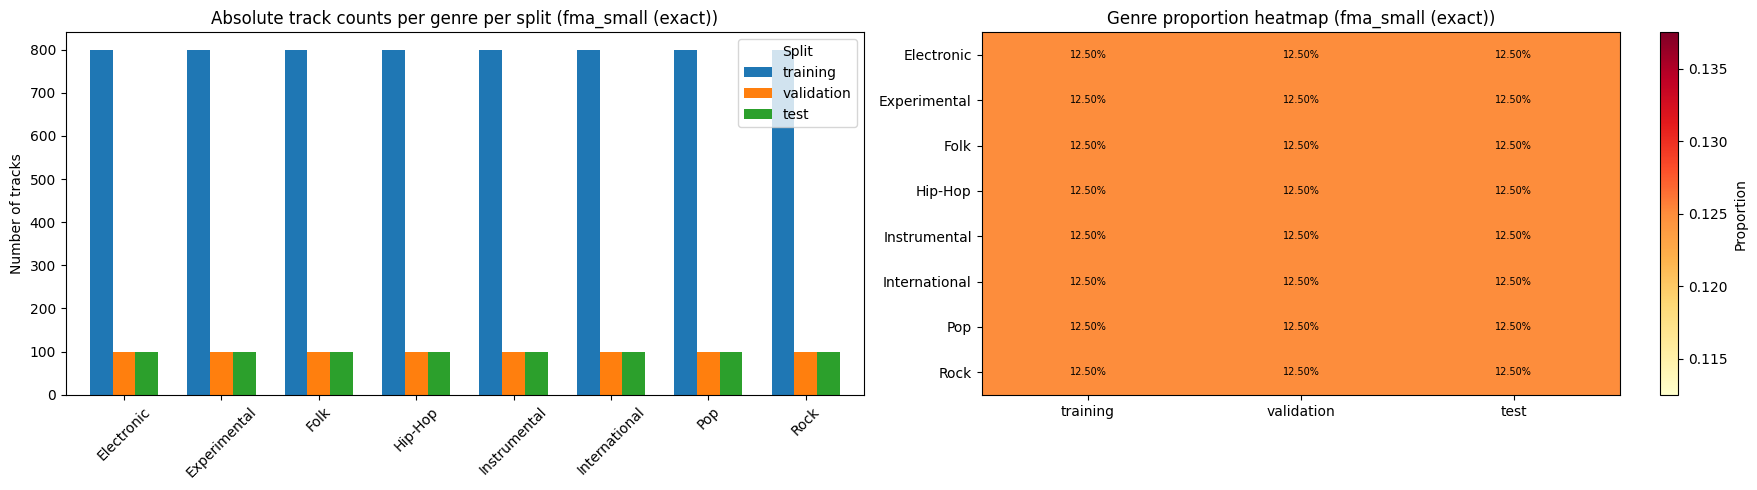

Chi-square test of homogeneity (are genre proportions the same?):
  Train vs Val  — χ²=0.00, dof=7, p=1.0000e+00
  Train vs Test — χ²=0.00, dof=7, p=1.0000e+00
  → Cannot reject H₀: distributions are statistically similar.


In [23]:

import scipy.stats as scipy_stats

# ── 5A) Absolute-count bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

counts[["training", "validation", "test"]].plot(
    kind="bar", ax=axes[0], width=0.7
)
axes[0].set_title(f"Absolute track counts per genre per split ({_subset_label})")
axes[0].set_ylabel("Number of tracks")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Split")

# ── 5B) Heatmap of proportions (genres × splits) ─────────────────────────────
heatmap_data = props[["training", "validation", "test"]]
im = axes[1].imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(heatmap_data.columns)))
axes[1].set_xticklabels(heatmap_data.columns)
axes[1].set_yticks(range(len(heatmap_data.index)))
axes[1].set_yticklabels(heatmap_data.index)
axes[1].set_title(f"Genre proportion heatmap ({_subset_label})")
plt.colorbar(im, ax=axes[1], label="Proportion")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        axes[1].text(j, i, f"{val:.2%}", ha="center", va="center", fontsize=7,
                     color="black" if val < 0.15 else "white")

plt.tight_layout()
plt.show()

# ── 5C) Chi-square test of homogeneity ───────────────────────────────────────
chi2_tv, p_tv, dof_tv, _ = scipy_stats.chi2_contingency(
    counts[["training", "validation"]].values
)
chi2_tt, p_tt, dof_tt, _ = scipy_stats.chi2_contingency(
    counts[["training", "test"]].values
)
print("Chi-square test of homogeneity (are genre proportions the same?):")
print(f"  Train vs Val  — χ²={chi2_tv:.2f}, dof={dof_tv}, p={p_tv:.4e}")
print(f"  Train vs Test — χ²={chi2_tt:.2f}, dof={dof_tt}, p={p_tt:.4e}")
if p_tv > 0.05 and p_tt > 0.05:
    print("  → Cannot reject H₀: distributions are statistically similar.")
else:
    print("  → Reject H₀: significant distribution difference detected.")


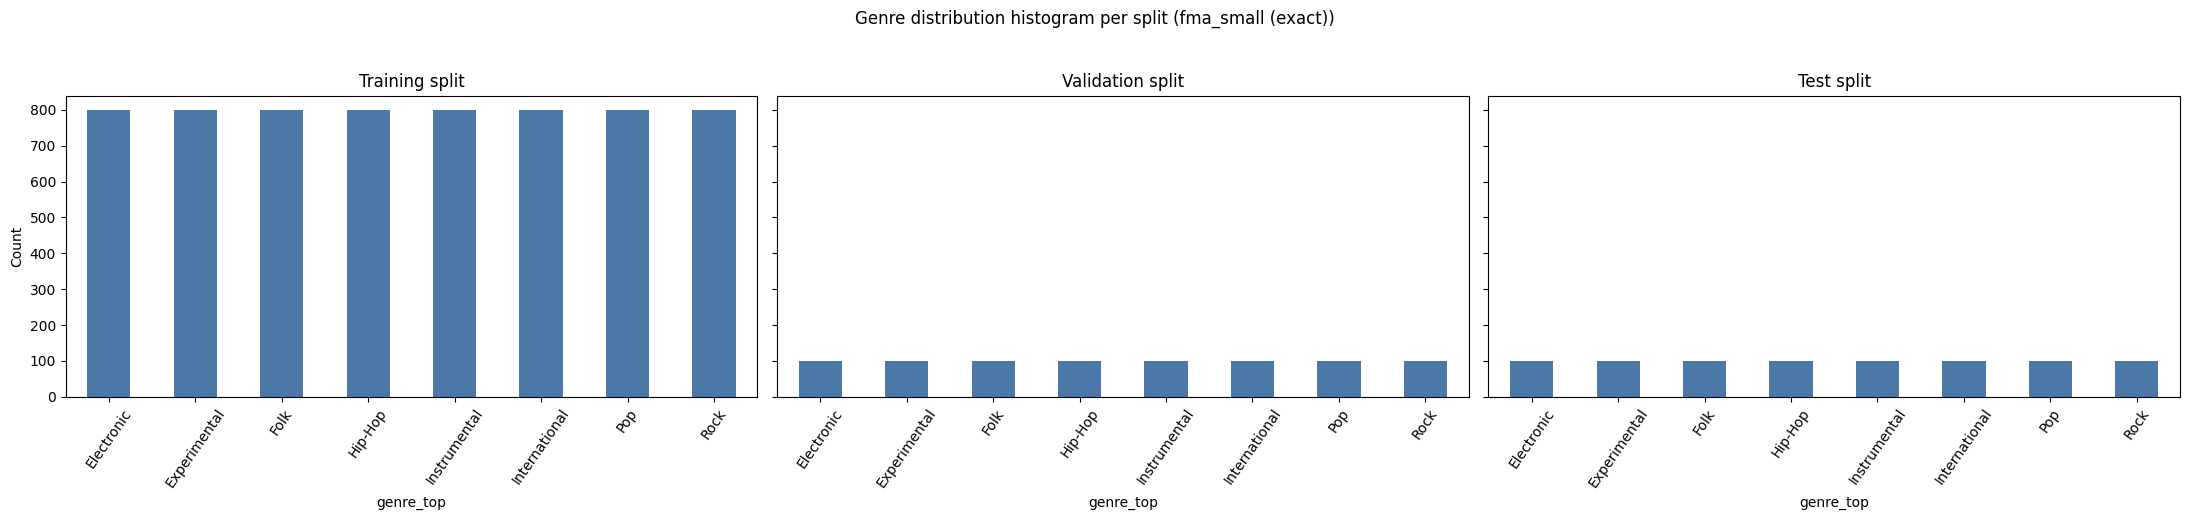

In [24]:

# 6) Distribution histograms by split (x = genre_top, y = count)
split_order = ["training", "validation", "test"]
fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)

for axis, split_name in zip(axes, split_order):
    split_counts = counts[split_name].sort_values(ascending=False)
    split_counts.plot(kind="bar", ax=axis, color="#4C78A8")
    axis.set_title(f"{split_name.capitalize()} split")
    axis.set_xlabel("genre_top")
    axis.set_ylabel("Count")
    axis.tick_params(axis="x", rotation=55)

plt.suptitle(f"Genre distribution histogram per split ({_subset_label})", y=1.03)
plt.tight_layout()
plt.show()


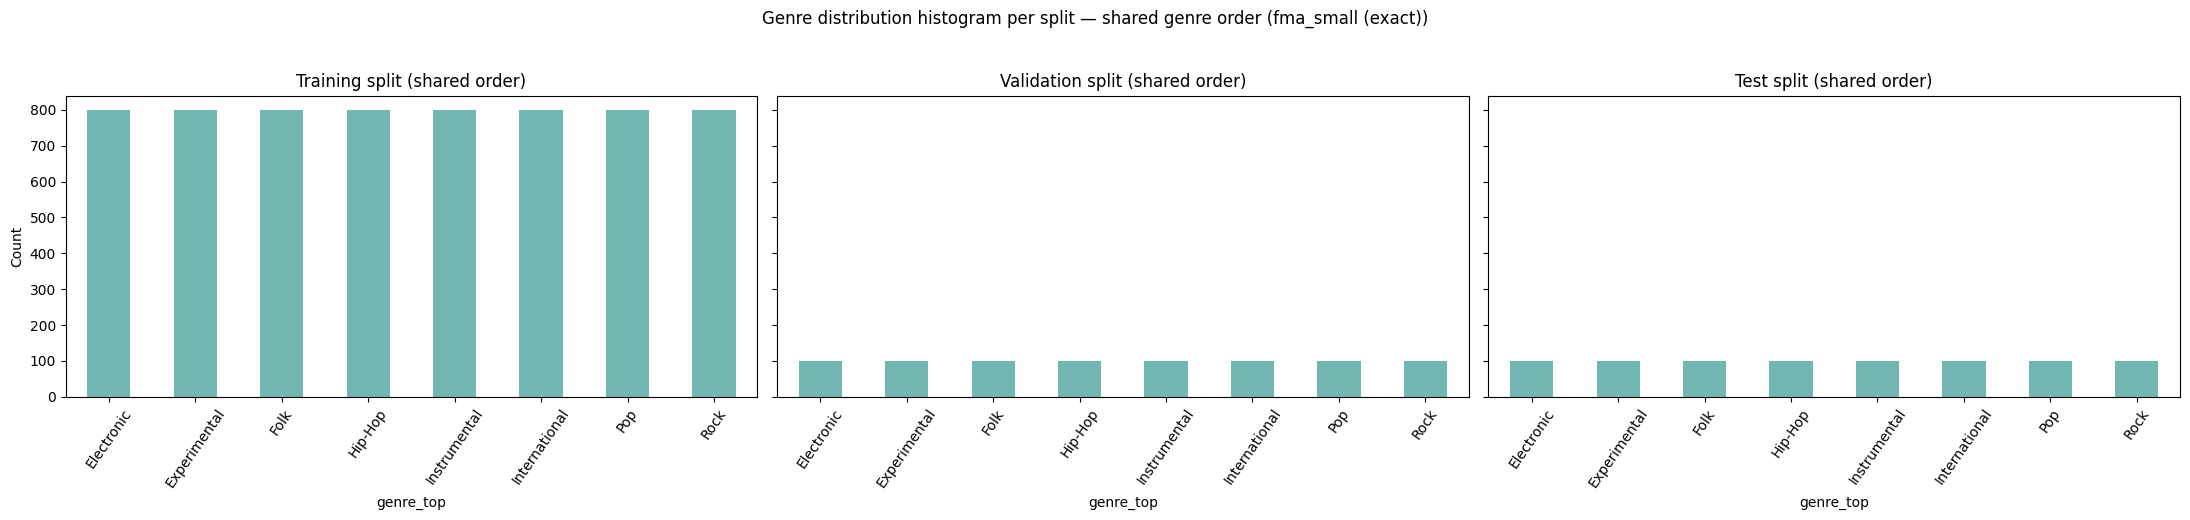

In [25]:

# 7) Distribution histograms by split with shared genre order
shared_genre_order = counts["training"].sort_values(ascending=False).index.tolist()
split_order = ["training", "validation", "test"]
fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)

for axis, split_name in zip(axes, split_order):
    split_counts = counts.loc[shared_genre_order, split_name]
    split_counts.plot(kind="bar", ax=axis, color="#72B7B2")
    axis.set_title(f"{split_name.capitalize()} split (shared order)")
    axis.set_xlabel("genre_top")
    axis.set_ylabel("Count")
    axis.tick_params(axis="x", rotation=55)

plt.suptitle(f"Genre distribution histogram per split — shared genre order ({_subset_label})", y=1.03)
plt.tight_layout()
plt.show()


---

# Result Interpretation

## How to read this notebook

This notebook is now **configuration-dependent**. The meaning of the results depends on:

- `SUBSET`
- `SUBSET_MODE`
- `TOP_N_GENRES`

So this section should be read as an **interpretation guide**, not as a fixed report with hardcoded numbers.

---

## 1) First check the dataset scope

Before interpreting any chart or table, look at the configuration printed near the top of the notebook.

### If `SUBSET="small"` and `SUBSET_MODE="exact"`

This should correspond to the official **FMA-small** setup described in the FMA repository:

- about **8,000 tracks**,
- **8 top genres**,
- and a much more balanced genre distribution than medium or large.

If this exact-small configuration shows many more than 8 genres, then the filtering logic is wrong or the notebook has not been re-run from the top after a code change.

### If `SUBSET_MODE="cumulative"`

Then the selected subset is interpreted as:

- `small` = small only,
- `medium` = small ∪ medium,
- `large` = small ∪ medium ∪ large.

In cumulative mode, it is normal to see:

- more tracks,
- more genres,
- and much stronger class imbalance.

That is expected behavior, not a bug.

---

## 2) Whole-dataset EDA interpretation

The whole-dataset section is for understanding the selected dataset *before* looking at train/validation/test splits.

### Label coverage

The labeled vs unlabeled counts tell you how much of the selected dataset actually has `genre_top` annotations.

- high unlabeled counts are expected when using broader subsets,
- because not every FMA row has a usable `genre_top` label.

### Exact subset composition

This chart is especially important in cumulative mode.

- In `exact` mode, you should mostly see one exact subset label.
- In `cumulative` mode, you should see a mixture of exact subset labels contributing to the selected dataset.

### Whole-dataset genre distribution

This shows whether the selected dataset is roughly balanced or strongly head-heavy.

- **Exact small** should look relatively balanced.
- **Medium/large** usually look much more imbalanced.

If you only care about the head of the distribution, `TOP_N_GENRES` limits the display to the most frequent genres without changing the underlying data.

### Supplementation band

The reported band

$$
0.05 < r_c \le 0.2
$$

is useful for identifying minority genres that are still large enough to be plausible supplementation candidates.

Interpret it as:

- these genres are meaningfully underrepresented,
- but not so tiny that duplication is immediately suspicious.

---

## 3) Split-distribution interpretation

The split-analysis cells answer a different question:

> Given the selected dataset scope, are the train / validation / test genre distributions reasonably similar?

### Counts and proportions

Use the counts table to inspect absolute support and the proportions table to inspect class mix.

- counts tell you whether a class has enough support to trust its per-genre metrics,
- proportions tell you whether the split distributions are shape-consistent.

### Drift ratios

For a genre $g$:

- `test/train` near $1.0$ means test is proportionally similar to train,
- `val/train` near $1.0$ means validation is proportionally similar to train.

Interpret large ratios carefully:

- for tiny classes, a small absolute count change can create a very large ratio,
- so ratios should always be read together with the raw counts.

### TVD and JSD

These are the best one-number summaries of split similarity in this notebook.

- small values mean the split distributions are operationally close,
- larger values mean the class mix differs more substantially.

As a practical rule:

- low TVD/JSD + stable dominant genres usually means the split is usable,
- high TVD/JSD + strong minority drift means evaluation should emphasize Macro-F1 and per-genre F1 even more strongly.

### Chi-square test

The chi-square test is often statistically significant on large datasets even when the practical difference is small.

So in this notebook:

- use chi-square as a signal that differences exist,
- but use TVD, JSD, raw counts, and drift tables to decide whether those differences matter operationally.

---

## 4) How to interpret the notebook for common configurations

### Case A — `SUBSET="small"`, `SUBSET_MODE="exact"`

Expected interpretation:

- the dataset should be close to the official FMA-small definition,
- the number of labeled genres should be close to 8,
- the class distribution should be much more balanced,
- and top-genre views mainly help readability rather than fixing a severe imbalance problem.

This is the cleanest setup for sanity checks and quick controlled experiments.

### Case B — `SUBSET="medium"`, `SUBSET_MODE="cumulative"`

Expected interpretation:

- more genres appear,
- imbalance is much stronger,
- minority classes can become very small relative to the head genres,
- and Macro-F1 becomes much more important than accuracy.

This is the more realistic setup for the main MelCNN-MGR training pipeline.

### Case C — `TOP_N_GENRES` is set

Expected interpretation:

- the plots and some printed views focus on the head of the distribution,
- but the notebook still computes full-dataset metrics unless a cell explicitly uses a top-genre view.

So `TOP_N_GENRES` is mainly a **display simplification**, not a data filter.

---

## 5) Practical guidance for MelCNN MGR

1. If you want to verify the official FMA-small claim, use `SUBSET="small"` and `SUBSET_MODE="exact"`.
2. If you want the broader training-style data view, use cumulative mode intentionally and expect more genres plus heavier imbalance.
3. If you only care about dominant genres, keep `TOP_N_GENRES` small for readability, but remember that tail genres still matter for Macro-F1.
4. Never rely on accuracy alone when the whole-dataset or split-level plots show clear head-tail imbalance.
5. When drift ratios look extreme, check the raw support counts before concluding that the split is badly mismatched.

---

## 6) Bottom line

This notebook should now be interpreted in two layers:

- **whole-dataset EDA** tells you what kind of dataset you selected,
- **split analysis** tells you whether train/validation/test preserve a similar class mix within that selected dataset.

If the configuration is exact FMA-small, results should align closely with the official FMA-small description.
If the configuration is cumulative medium or large, more genres and stronger imbalance are expected and should be treated as part of the data definition, not as an error.